In [44]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sn

#import warnings
#warnings.filterwarnings('ignore')

#pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [45]:
data = pd.read_csv('advertising.csv')
data.head(5)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [46]:
data.rename(columns = {'Male':'Sex'}, inplace=True)

In [47]:
data.round(2)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Sex,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0
...,...,...,...,...,...,...,...,...,...,...
995,72.97,30,71384.57,208.58,Fundamental modular algorithm,Duffystad,1,Lebanon,2016-02-11 21:49:00,1
996,51.30,45,67782.17,134.42,Grass-roots cohesive monitoring,New Darlene,1,Bosnia and Herzegovina,2016-04-22 02:07:01,1
997,51.63,51,42415.72,120.37,Expanded intangible solution,South Jessica,1,Mongolia,2016-02-01 17:24:57,1
998,55.55,19,41920.79,187.95,Proactive bandwidth-monitored policy,West Steven,0,Guatemala,2016-03-24 02:35:54,0


In [48]:
#Data timestamp needs to be converted.
data = data.drop('Ad Topic Line', axis = 1)
data = data.drop('Timestamp', axis = 1)

In [49]:
data.dtypes

Daily Time Spent on Site    float64
Age                           int64
Area Income                 float64
Daily Internet Usage        float64
City                            str
Sex                           int64
Country                         str
Clicked on Ad                 int64
dtype: object

In [50]:
data['Clicked on Ad'].value_counts()

Clicked on Ad
0    500
1    500
Name: count, dtype: int64

In [51]:
#descriptive stats - mean, std dev
data.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Sex,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


In [52]:
data.isnull().sum()

Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
City                        0
Sex                         0
Country                     0
Clicked on Ad               0
dtype: int64

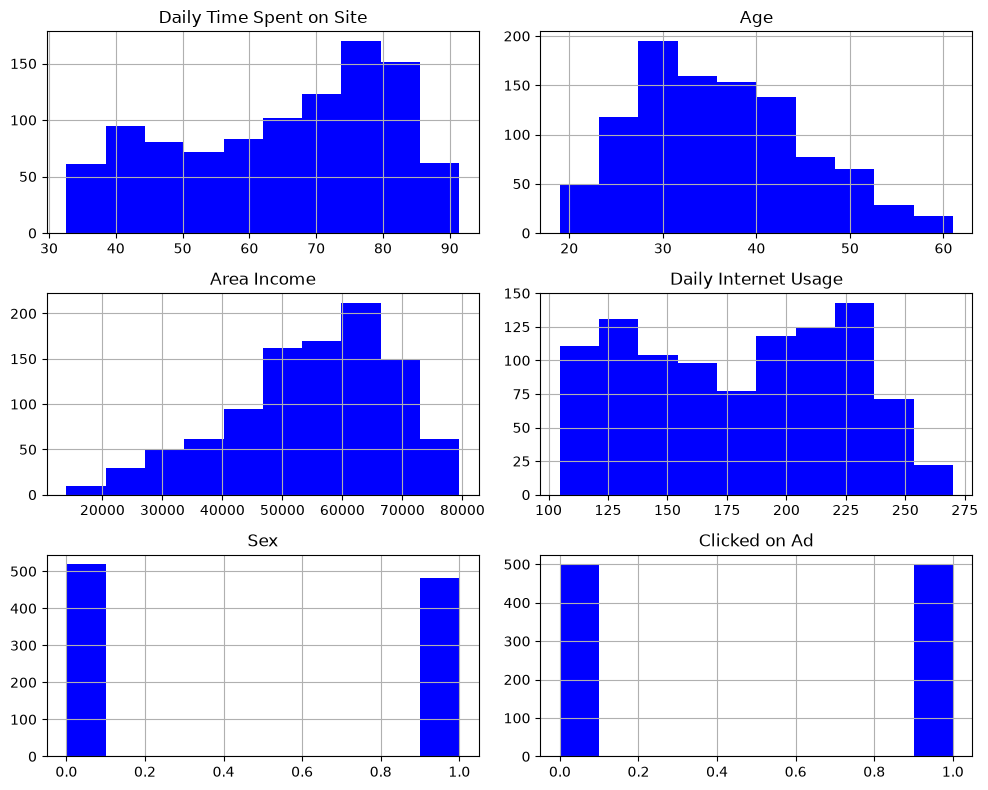

In [53]:
numerical_data = data.select_dtypes(include='number')
numerical_data.hist(figsize=(10,8), color = 'b')
plt.tight_layout()
plt.show()

In [54]:
#Drop any irrelavant columns. 
#data.drop(['New_Customer'], axis =1, inplace = True)
#data.head()
#corr().head()

In [55]:
#To determine which columns are related to 'Lifetime'. (Ordered target column & highest correlation)
correlation = numerical_data.corr()['Clicked on Ad']
correlation.nlargest(10).round(2)

Clicked on Ad               1.00
Age                         0.49
Sex                        -0.04
Area Income                -0.48
Daily Time Spent on Site   -0.75
Daily Internet Usage       -0.79
Name: Clicked on Ad, dtype: float64

<Axes: >

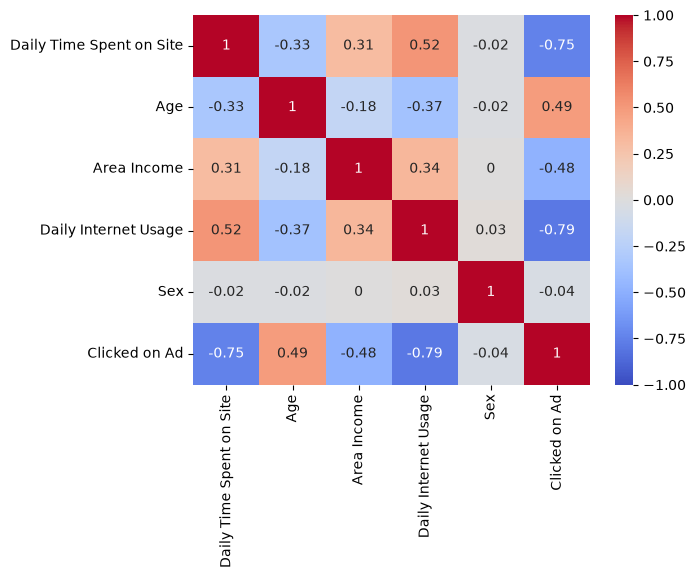

In [56]:
#to display correlations using a heatmap using Seaborn library.
#f,ax = plt.subplots(figsize=(10,8))

corr = numerical_data.corr()
sn.heatmap(corr.round(2), annot=True,vmin =-1, vmax=1, center=0,cmap="coolwarm")

<Axes: >

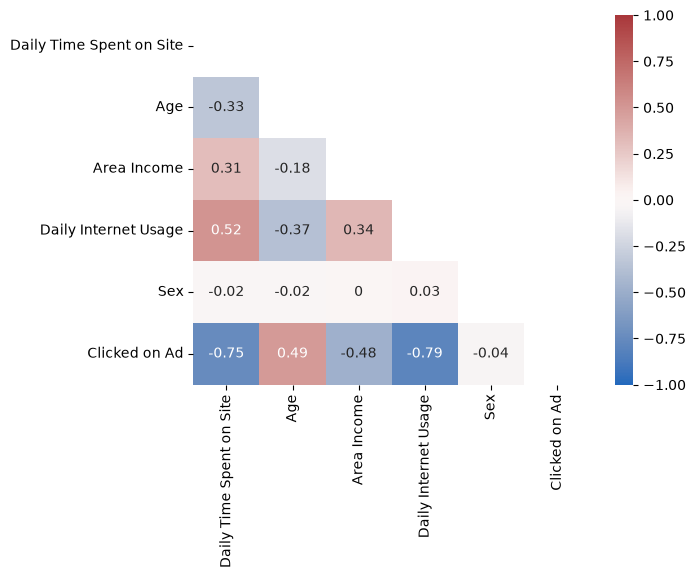

In [57]:
#to display correlations use mask function
matrix = numerical_data.corr().round(2)
mask = np.triu(np.ones_like(matrix, dtype=bool))
sn.heatmap(corr.round(2), annot=True,vmin =-1, vmax=1, center=0,cmap="vlag", mask=mask)

In [58]:
#to view largest matrix to Lifetime Value
matrix['Clicked on Ad'].nlargest(10)

Clicked on Ad               1.00
Age                         0.49
Sex                        -0.04
Area Income                -0.48
Daily Time Spent on Site   -0.75
Daily Internet Usage       -0.79
Name: Clicked on Ad, dtype: float64

In [59]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = le.fit_transform(data[col])
data.dtypes

C:\Users\mcnicholst\AppData\Local\Temp\ipykernel_15100\1142123476.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data.select_dtypes(include=['object']).columns:


Daily Time Spent on Site    float64
Age                           int64
Area Income                 float64
Daily Internet Usage        float64
City                          int64
Sex                           int64
Country                       int64
Clicked on Ad                 int64
dtype: object

In [60]:
data['City'].nunique()

969

In [61]:
data.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,City,Sex,Country,Clicked on Ad
0,68.95,35,61833.90,256.09,961,0,215,0
1,80.23,31,68441.85,193.77,903,1,147,0
2,69.47,26,59785.94,236.50,111,0,184,0
3,74.15,29,54806.18,245.89,939,1,103,0
4,68.37,35,73889.99,225.58,805,0,96,0


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# =====================================================================
# 1. Load / Mock the Demographics & Advertising CSV Dataset
# =====================================================================
#np.random.seed(42)
#n_samples = 1000

#data = {
  #  'User_Age': np.random.randint(18, 65, size=n_samples),
  #  'Annual_Income_EUR': np.random.normal(45000, 15000, size=n_samples).round(2),
  #  'User_Region': np.random.choice(['Dublin', 'Leinster', 'Munster', 'Connacht-Ulster'], size=n_samples),
  #  'Ad_Spend_Social': np.random.uniform(5, 500, size=n_samples).round(2),
  #  'Ad_Spend_Search': np.random.uniform(10, 300, size=n_samples).round(2),
  #  'Ad_Spend_Email': np.random.uniform(0, 100, size=n_samples).round(2),
#}

#df = pd.DataFrame(data)

# Simulate target variable logic (Campaign_Success: 1 or 0)
#log_odds = (
    #0.05 * (df['User_Age'] - 35) + 
   # 0.0001 * (df['Annual_Income_EUR'] - 45000) +
   # 0.01 * df['Ad_Spend_Social'] + 
   # (df['User_Region'] == 'Dublin') * 0.5 - 2.5
#)
#probability = 1 / (1 + np.exp(-log_odds))
df['Campaign_Success'] = np.random.binomial(1, probability)

# Separate features and target
X = df.drop(columns=['Campaign_Success'])
y = df['Campaign_Success']

# =====================================================================
# 2. Pipeline Configuration & Model Training (Random Forest)
# =====================================================================
numeric_features = ['User_Age', 'Annual_Income_EUR', 'Ad_Spend_Social', 'Ad_Spend_Search', 'Ad_Spend_Email']
categorical_features = ['User_Region']

# Standardize values and encode non-numeric strings
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

# Build pipeline using Random Forest Classifier
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Split data (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Train the model
rf_pipeline.fit(X_train, y_train)

# Predict target tags
y_pred = rf_pipeline.predict(X_test)

# =====================================================================
# 3. Text & Visual Metrics Evaluation
# =====================================================================
print("\n--- Random Forest Classification Performance ---")
print(classification_report(y_test, y_pred))

# Get explicit feature names from the transformer pipeline
encoded_cat_features = rf_pipeline.named_steps['preprocessor']\
                                  .named_transformers_['cat']\
                                  .get_feature_names_out(categorical_features).tolist()
all_features = numeric_features + encoded_cat_features

# Extract Feature Importances directly from the trained tree ensemble
importances = rf_pipeline.named_steps['classifier'].feature_importances_
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n--- Demographics & Advertising Feature Importances ---")
print(importance_df.to_string(index=False))

# Generate Clean Confusion Matrix & Feature Importance Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Failure (0)', 'Success (1)'],
            yticklabels=['Failure (0)', 'Success (1)'])
axes[0].set_title('Confusion Matrix Matrix')
axes[0].set_xlabel('Predicted Identity')
axes[0].set_ylabel('True Historical Identity')

# Plot B: Feature Importance Bar Chart
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', ax=axes[1])
axes[1].set_title('Random Forest Feature Importance')
axes[1].set_xlabel('Relative Importance Weight')

plt.tight_layout()
plt.show()


In [62]:

# Ensure your model pipeline ('rf_pipeline') has already been fitted before running this:
# rf_pipeline.fit(X_train, y_train)

# 1. Retrieve structural feature names from the preprocessor step
# This extracts the numeric names and the newly generated One-Hot Encoded categorical strings
numeric_features = ['User_Age', 'Annual_Income_EUR', 'Ad_Spend_Social', 'Ad_Spend_Search', 'Ad_Spend_Email']
categorical_features = ['User_Region']

encoded_cat_features = rf_pipeline.named_steps['preprocessor'] \
                                  .named_transformers_['cat'] \
                                  .get_feature_names_out(categorical_features).tolist()

# Combine lists to create a master key of all features fed into the Random Forest
all_features = numeric_features + encoded_cat_features

# 2. Extract relative mathematical importance coefficients from the classifier step
raw_importances = rf_pipeline.named_steps['classifier'].feature_importances_

# 3. Pair features with their importance values into a readable DataFrame
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Relative_Importance': raw_importances
}).sort_values(by='Relative_Importance', ascending=False)

# 4. Display the raw sorted text output
print("\n=== CAMPAIGN CONVERSION DRIVERS ===")
for index, row in importance_df.iterrows():
    print(f"-> {row['Feature']:<30} Importance: {row['Relative_Importance']:.4f}")

# 5. Visualize the feature impact hierarchy
plt.figure(figsize=(10, 5))
sns.barplot(
    x='Relative_Importance', 
    y='Feature', 
    data=importance_df, 
    palette='magma', 
    hue='Feature', 
    legend=False
)

plt.title('What Drove the Conversion? (Feature Importance Ranking)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Relative Predictive Weight (Sum = 1.0)', fontsize=11)
plt.ylabel('Feature Attributes', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


AttributeError: 'ColumnTransformer' object has no attribute 'transformers_'

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# =====================================================================
# 1. Pipeline Alignment (Using your exact notebook fields)
# =====================================================================
# Setting up predictors and targets matching your notebook structure
X = data[['Age', 'Daily Internet Usage']]
y = data['Clicked on Ad']

# 70:30 Split as noted in your image commentary
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Correct model assignment (Classifier instead of raw Linear Regression)
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

# Evaluate true classification accuracy
predictions = classifier.predict(X_test)
acc = accuracy_score(y_test, predictions)
print(f"True Classification Accuracy: {acc:.4f} ({acc*100:.1f}%)")

# =====================================================================
# 2. Extracting True Probabilities for New Customers
# =====================================================================
# Creating a 2D array matching your exact test scenarios
# Note: Restoring daily usage parameters to realistic bounds for a 24-hr day
combined_data = np.array([
    [30, 100],  # Customer 1: Age 30, 100 mins daily usage
    [50, 240]   # Customer 2: Age 50, 240 mins daily usage (max realistic usage)
])

# Use predict_proba instead of predict to get probabilities for each class
# [:, 1] extracts column 1: the exact probability of clicking the ad (Class 1)
probabilities = classifier.predict_proba(combined_data)[:, 1]

# Convert to percentage strings for clear console display
print("\n--- Predicted Ad Click Likelihood ---")
print(f"Customer 1 Probability: {probabilities[0]*100:.2f}% chance to click")
print(f"Customer 2 Probability: {probabilities[1]*100:.2f}% chance to click")

# =====================================================================
# 3. Bar Charting the Probabilities
# =====================================================================
labels = ['Customer 1\n(30 yrs, 100m usage)', 'Customer 2\n(50 yrs, 240m usage)']

plt.figure(figsize=(7, 5))
# Generate bars representing probabilities directly
bars = plt.bar(labels, probabilities, color=['#3498db', '#e74c3c'], edgecolor='black', width=0.5)

# Style constraints ensuring bounds stick strictly to 0.0 - 1.0 (0% to 100%)
plt.ylim(0, 1.05)
plt.ylabel('Ad Click Probability (0.0 to 1.0)')
plt.title('Ad Click Prediction Comparison (Logistic Regression)')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Threshold (50%)')

# Annotate values onto the top of each bar element
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval*100:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from  sklearn.linear_model import LinearRegression
import sklearn.metrics

#Create a an Algorithm that can learn and make predictions in a task.
#predictors = data[[']]
predictors = data[['Age','Daily Internet Usage']]
targets = data['Clicked on Ad']

In [ ]:
#to show the info.
#predictors.shape

In [ ]:
#To train and test the data - use ration of 70:30 (70% of the data is used to train the model & 30% to test the model).
X= data
Y= data['Clicked on Ad']
#pred_train,pred_test,tar_train,tar_test = train_test_split(X,Y, test_size = .2)
#print('Predictor for Predictor Training: ', y_train.shape, 'Predictor for Testing: ',y_test.shape)
#print('Predictor for Target Training: ', tar_train.shape, 'Predictor for Target Testing: ',tar_test.shape)
pred_train, pred_test, tar_train, tar_test = train_test_split(predictors, targets, test_size = .2)
print('Predictor - Training: ', pred_train.shape, 'Predictor - Testing: ',pred_test.shape)


In [ ]:
pred_train.head()

In [ ]:
#Build a linear Regression model based on training data.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import sklearn.metrics

model = LinearRegression()
model.fit(pred_train,tar_train)
print ("Coefficients: \n", model.coef_)
print("Intercept: ", model.intercept_)

#Test the test on testing data
predictions = model.predict(pred_test)
predictions


In [ ]:
#Use a preexisting Naive Bayes Classifier to create a matrix array.

from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier = classifier.fit(pred_train, tar_train)
predictions = classifier.predict(pred_test)

sklearn.metrics.confusion_matrix(tar_test, predictions)

In [ ]:
#Output to show the accuracy of the model of predicting Cusomter Lifetime Value.
print("Accuracy of the model: ", sklearn.metrics.r2_score(tar_test,predictions).round())

In [ ]:
#Predict the Clicked Ads for a new customer.  1.07 chance
#Aged 30 & 100 hours internet
#Use this to predict the new customer value.

new_data = np.array([30,100]).reshape(1,-1)
new_pred=model.predict(new_data)
print ('The Ad clicks for the customer - aged 30, 100, = ', new_pred[0].round(2)) 

In [ ]:
# To plot the prediction as a point or bar:
plt.bar(["Customer"], new_pred[0])
plt.ylabel("Predicted Ad Clicks")
plt.show()

In [ ]:
#Predict the Clicked Ads for a new customer.
#Aged 50 & 500 hours internet.
#Use this to predict the new customer value.

new_data = np.array([50,500]).reshape(1,-1)
new_pred=model.predict(new_data)
print ('The Ad clicks for the customer - aged 30, 100, = ', new_pred[0].round(2)) 

In [ ]:
# 1. Combine both customer inputs into a single 2D array
combined_data = np.array([[30, 100],  # Customer 1: Age 30, 100 hours
    [50, 500]   # Customer 2: Age 50, 500 hours
])

# 2. Get predictions for both customers at once
predictions = model.predict(combined_data)

# 3. Create a bar chart to compare them
labels = ['Customer 1 (30 yrs, 100h)', 'Customer 2 (50 yrs, 500h)']
plt.bar(labels, predictions, color=['blue', 'orange'])
plt.ylabel('Predicted Ad Clicks')
plt.title('Ad Click Prediction Comparison')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--') # Line at 0 for negative values
plt.show()


In [ ]:

from mpl_toolkits.mplot3d import Axes3D

# 1. Define the features for your customers
# [Age, Internet Hours]
ages = np.array([30, 50])
internet_hours = np.array([100, 500])

# Combine into a single array for prediction
combined_data = np.column_stack((ages, internet_hours))
predictions = model.predict(combined_data)

# 2. Set up the 3D canvas
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplots(111, projection='3d')

# 3. Scatter the prediction points
# c determines the color mapping based on prediction value
scatter = ax.scatter(ages, internet_hours, predictions, c=predictions, cmap='coolwarm', s=100, edgecolors='black')

# 4. Add labels and titles
ax.set_xlabel('Age')
ax.set_ylabel('Internet Hours')
ax.set_zlabel('Predicted Ad Clicks')
ax.set_title('3D View of Customer Ad Click Predictions')

# Add a color bar side-legend to map color to prediction value
fig.colorbar(scatter, ax=ax, label='Prediction Value', pad=0.1)

plt.show()


# Prediction model is important because it allows the company to predict what Ads are most likely to get the highest value - therefore prioritise 'best' Ads to a Return on Investment (ROI).